# Fraud Transaction Risk Intelligence
## 02 — Fraud Exploratory Data Analysis

Explore transaction patterns and identify factors associated with fraudulent activity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 1. Load Prepared Data

Load the cleaned and merged dataset created in the data preparation stage.

In [2]:
DATA_PATH = "../data/processed/train_prepared.parquet"

train = pd.read_parquet(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", train.shape)

Dataset loaded successfully!
Shape: (590540, 434)


## 2. Dataset Overview

Review the structure and basic statistics of the prepared dataset.

In [3]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float32(399), int16(1), int32(2), int8(1), str(31)
memory usage: 1.0 GB


In [5]:
train.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,NaN,NaN,NaN,3282269.5,170474.358321,2987000.0,3134634.75,3282269.5,3429904.25,3577539.0
isFraud,590540.0,NaN,NaN,NaN,0.03499,0.183755,0.0,0.0,0.0,0.0,1.0
TransactionDT,590540.0,NaN,NaN,NaN,7372311.310116,4617223.64654,86400.0,3027057.75,7306527.5,11246620.0,15811131.0
TransactionAmt,590540.0,NaN,NaN,NaN,135.027176,239.162521,0.251,43.320999,68.769001,125.0,31937.390625
ProductCD,590540,5,W,439670,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card1,590540.0,NaN,NaN,NaN,9898.734658,4901.170153,1000.0,6019.0,9678.0,14184.0,18396.0
card2,581607.0,NaN,NaN,NaN,362.555511,157.793243,100.0,214.0,361.0,512.0,600.0
card3,588975.0,NaN,NaN,NaN,153.194931,11.336444,100.0,150.0,150.0,150.0,231.0
card4,588963,4,visa,384767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card5,586281.0,NaN,NaN,NaN,199.2789,41.244453,100.0,166.0,226.0,226.0,237.0


## 3. Fraud Distribution

Measure the imbalance between fraudulent and legitimate transactions.

In [6]:
fraud_counts = train["isFraud"].value_counts()

fraud_percent = (
    train["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Transaction Count:")
print(fraud_counts)

print("\nTransaction Percentage:")
print(fraud_percent)

Transaction Count:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Transaction Percentage:
isFraud
0    96.5
1     3.5
Name: proportion, dtype: float64


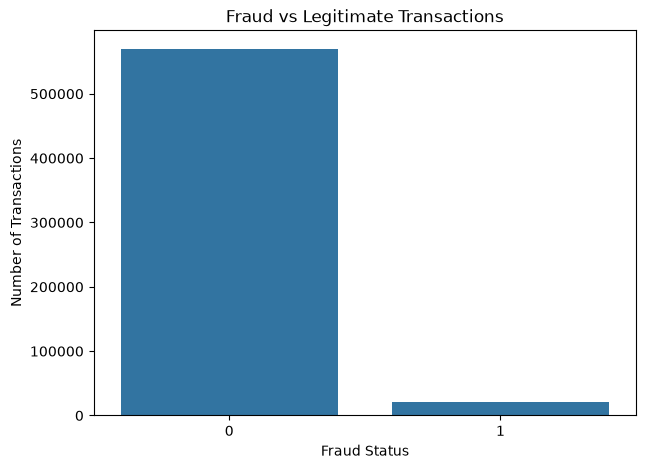

In [7]:
# Visualize Fraud vs Legitimate Transactions
plt.figure(figsize=(7, 5))

sns.countplot(
    data=train,
    x="isFraud"
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

plt.show()

### Observation

Fraudulent transactions represent a small proportion of the dataset, confirming a strong class imbalance.

## 4. Transaction Amount Analysis

Compare transaction amounts between fraudulent and legitimate transactions.

In [8]:
train.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511658,239.395081,0.251,43.970001,68.5,120.0,31937.390625
1,20663.0,149.244766,232.212158,0.292,35.043999,75.0,161.0,5191.000000


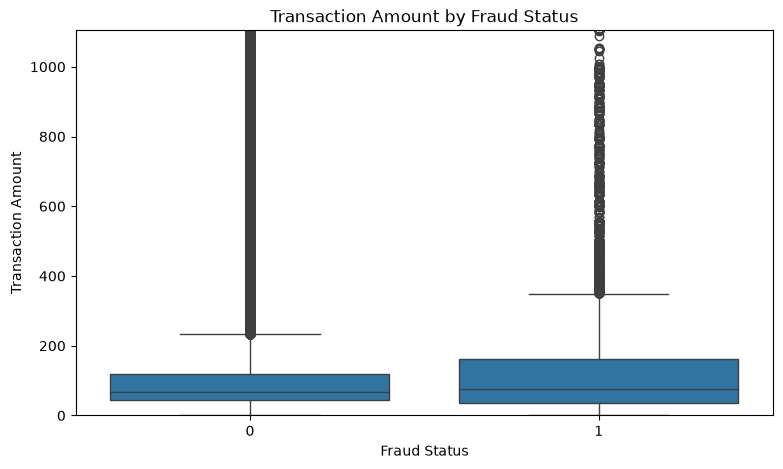

In [9]:
# Visualize Transaction Amount by Fraud Status
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=train,
    x="isFraud",
    y="TransactionAmt"
)

plt.ylim(0, train["TransactionAmt"].quantile(0.99))

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount")

plt.show()

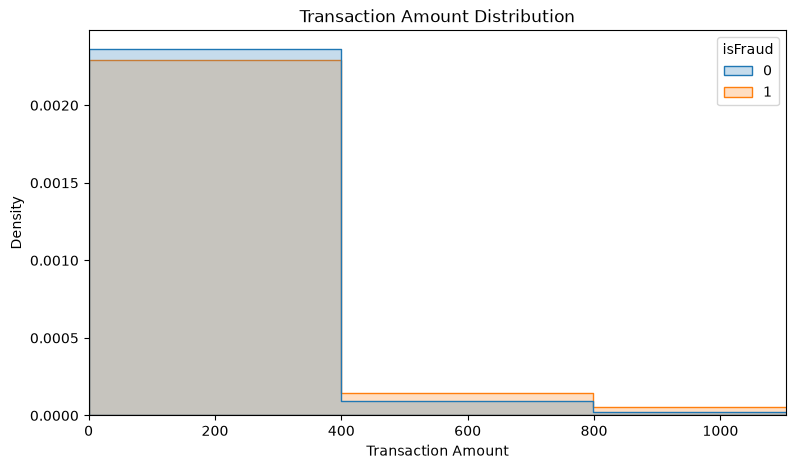

In [10]:
# Visualize Transaction Amount Distribution
plt.figure(figsize=(9, 5))

sns.histplot(
    data=train,
    x="TransactionAmt",
    hue="isFraud",
    bins=80,
    element="step",
    stat="density",
    common_norm=False
)

plt.xlim(0, train["TransactionAmt"].quantile(0.99))

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.show()

## 5. Fraud Rate by Transaction Amount

Group transactions into amount bands to identify ranges with higher fraud rates.

In [11]:
train["AmountBin"] = pd.qcut(
    train["TransactionAmt"],
    q=10,
    duplicates="drop"
)

amount_fraud_rate = (
    train.groupby("AmountBin", observed=True)["isFraud"]
    .mean()
    .mul(100)
    .reset_index(name="FraudRate")
)

amount_fraud_rate

,AmountBin,FraudRate
0,"(0.25, 25.95]",5.588883
1,"(25.95, 35.95]",3.205191
2,"(35.95, 49.0]",3.225014
3,"(49.0, 57.95]",1.943099
4,"(57.95, 68.769]",2.851295
5,"(68.769, 100.0]",3.616955
6,"(100.0, 117.0]",1.974223
7,"(117.0, 159.95]",4.302602
8,"(159.95, 275.293]",3.803734
9,"(275.293, 31937.391]",5.086956


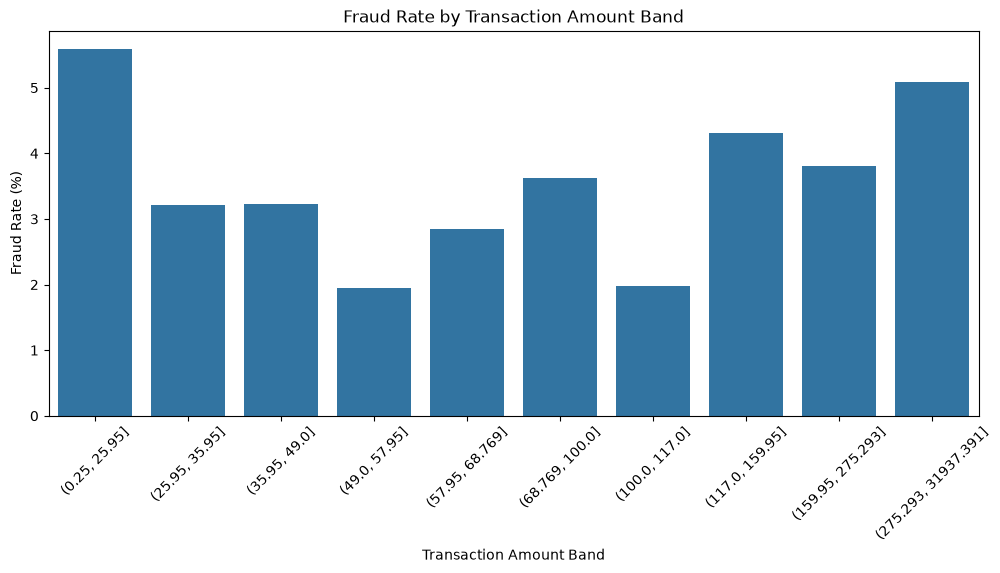

In [12]:
# Visualize Fraud Rate by Transaction Amount Band
plt.figure(figsize=(12, 5))

sns.barplot(
    data=amount_fraud_rate,
    x="AmountBin",
    y="FraudRate"
)

plt.title("Fraud Rate by Transaction Amount Band")
plt.xlabel("Transaction Amount Band")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.show()

## 6. Transaction Time Analysis

Examine whether fraudulent activity varies across transaction time.

In [13]:
train["TransactionHour"] = (
    (train["TransactionDT"] // 3600) % 24
).astype(int)

train["TransactionDay"] = (
    train["TransactionDT"] // (24 * 3600)
).astype(int)

In [14]:
hourly_fraud = (
    train.groupby("TransactionHour")["isFraud"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

hourly_fraud["FraudRate"] = hourly_fraud["mean"] * 100

hourly_fraud.head()

,TransactionHour,count,sum,mean,FraudRate
0,0,37795,1186,0.031380,3.137981
1,1,32797,1027,0.031314,3.131384
2,2,26732,1002,0.037483,3.748317
3,3,20802,797,0.038314,3.831362
4,4,14839,770,0.051890,5.189029


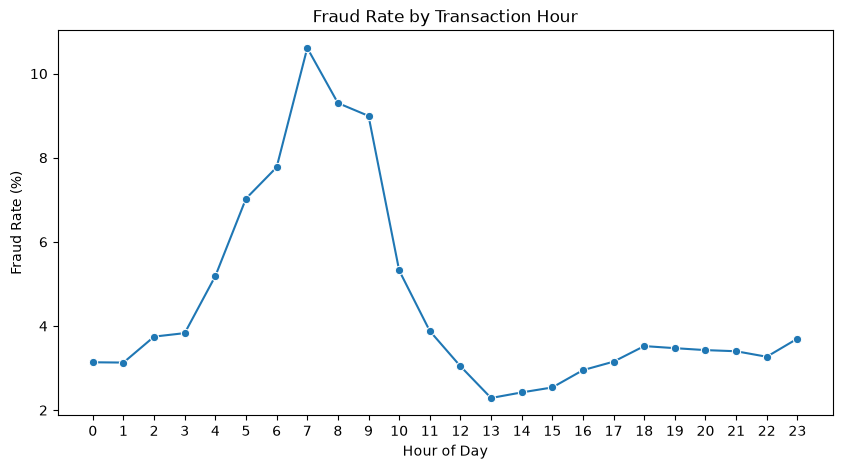

In [15]:
# Visualize Fraud Rate by Transaction Hour
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_fraud,
    x="TransactionHour",
    y="FraudRate",
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")

plt.xticks(range(24))

plt.show()

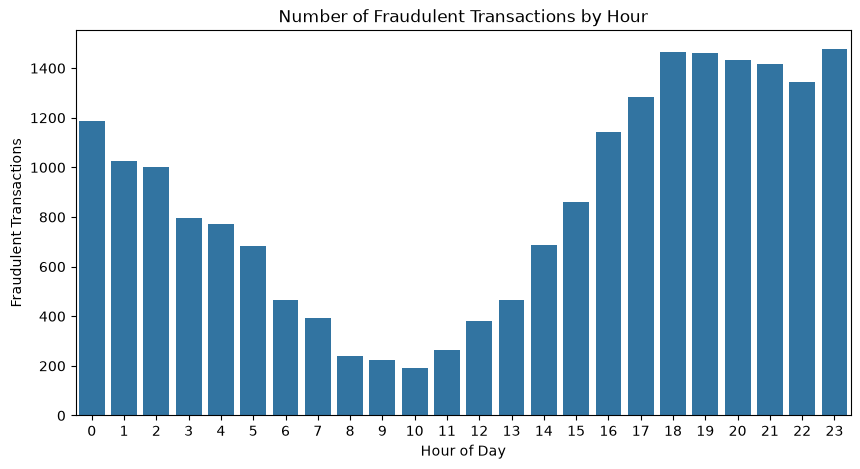

In [16]:
hourly_volume = (
    train.groupby("TransactionHour")["isFraud"]
    .sum()
    .reset_index(name="FraudCount")
)

# Visualize Number of Fraudulent Transactions by Hour
plt.figure(figsize=(10, 5))

sns.barplot(
    data=hourly_volume,
    x="TransactionHour",
    y="FraudCount"
)

plt.title("Number of Fraudulent Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraudulent Transactions")

plt.show()

## 7. Card and Payment Patterns

Examine selected card-related variables to identify differences between fraudulent and legitimate transactions.

In [17]:
# Identify Card-related Columns
card_columns = [
    col for col in train.columns
    if col.startswith("card")
]

card_columns[:20]

['card1', 'card2', 'card3', 'card4', 'card5', 'card6']

In [18]:
# Check for Missing Values in Card-related Columns
card_missing = (
    train[card_columns]
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

card_missing.head(20)

card2    1.512683
card5    0.721204
card4    0.267044
card6    0.266028
card3    0.265012
card1    0.000000
dtype: float64

In [19]:
# Analyze card4
if "card4" in train.columns:
    card4_fraud = (
        train.groupby("card4")["isFraud"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print(card4_fraud)

card4
discover            7.728161
visa                3.475610
mastercard          3.433095
american express    2.869837
Name: isFraud, dtype: float64


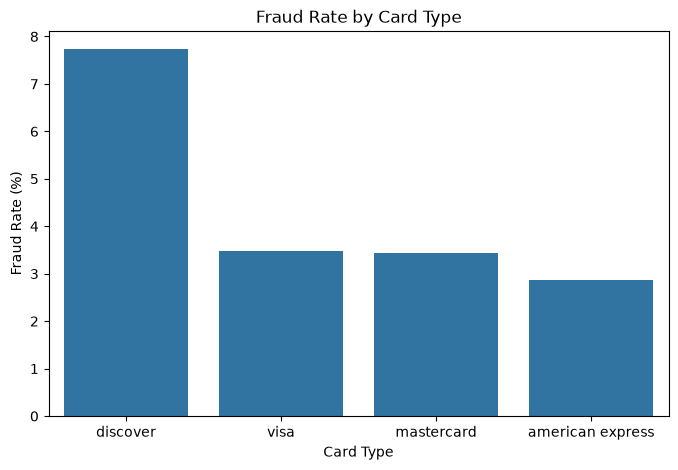

In [20]:
# Visualize Fraud Rate by Card Type
if "card4" in train.columns:
    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=card4_fraud.index,
        y=card4_fraud.values
    )

    plt.title("Fraud Rate by Card Type")
    plt.xlabel("Card Type")
    plt.ylabel("Fraud Rate (%)")

    plt.show()

In [21]:
# Analyze card6
if "card6" in train.columns:
    card6_fraud = (
        train.groupby("card6")["isFraud"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print(card6_fraud)

card6
credit             6.678480
debit              2.426251
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64


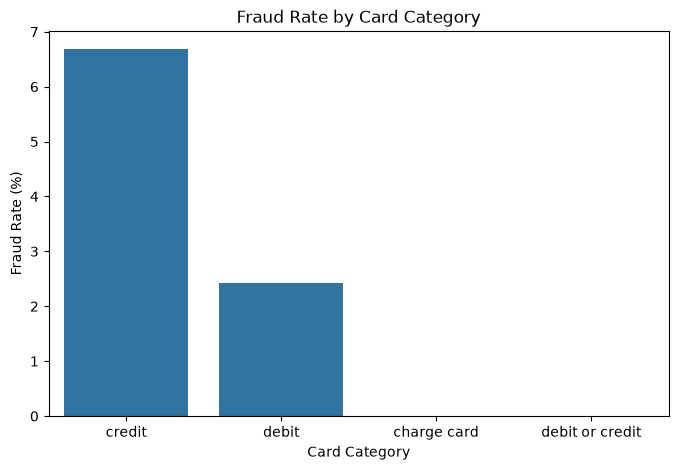

In [22]:
# Visualize card6
if "card6" in train.columns:
    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=card6_fraud.index,
        y=card6_fraud.values
    )

    plt.title("Fraud Rate by Card Category")
    plt.xlabel("Card Category")
    plt.ylabel("Fraud Rate (%)")

    plt.show()

## 8. Email Domain Patterns

Compare fraud rates across major purchaser and recipient email domains.

In [23]:
# Analyze Email Domain Columns
email_columns = [
    col for col in ["P_emaildomain", "R_emaildomain"]
    if col in train.columns
]

email_columns

['P_emaildomain', 'R_emaildomain']

In [24]:
# Analyze Email Domain Columns
for col in email_columns:
    print(f"\nTop values for {col}:")
    print(train[col].value_counts(dropna=False).head(15))


Top values for P_emaildomain:
P_emaildomain
gmail.com        228355
yahoo.com        100934
NaN               94456
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
live.com           3041
sbcglobal.net      2970
verizon.net        2705
ymail.com          2396
Name: count, dtype: int64

Top values for R_emaildomain:
R_emaildomain
NaN              453249
gmail.com         57147
hotmail.com       27509
anonymous.com     20529
yahoo.com         11842
aol.com            3701
outlook.com        2507
comcast.net        1812
yahoo.com.mx       1508
icloud.com         1398
msn.com             852
live.com            762
live.com.mx         754
verizon.net         620
me.com              556
Name: count, dtype: int64


In [25]:
if "P_emaildomain" in train.columns:

    top_domains = (
        train["P_emaildomain"]
        .value_counts()
        .head(15)
        .index
    )

    domain_fraud = (
        train[train["P_emaildomain"].isin(top_domains)]
        .groupby("P_emaildomain")["isFraud"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    domain_fraud

## 9. Device and Identity Patterns

Explore device and identity variables to determine whether certain groups show different fraud rates.

In [26]:
identity_columns = [
    col for col in train.columns
    if col.startswith("id_")
]

print("Identity features:", len(identity_columns))
print(identity_columns[:20])

Identity features: 38
['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20']


In [27]:
identity_missing = (
    train[identity_columns]
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

identity_missing.head(20)

id_24    99.196159
id_25    99.130965
id_08    99.127070
id_07    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_22    99.124699
id_23    99.124699
id_18    92.360721
id_03    88.768923
id_04    88.768923
id_33    87.589494
id_09    87.312290
id_10    87.312290
id_30    86.865411
id_32    86.861855
id_34    86.824771
id_14    86.445626
id_13    78.440072
dtype: float64

In [28]:
if "DeviceType" in train.columns:

    device_fraud = (
        train.groupby("DeviceType")["isFraud"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print(device_fraud)

DeviceType
mobile     10.166232
desktop     6.521458
Name: isFraud, dtype: float64


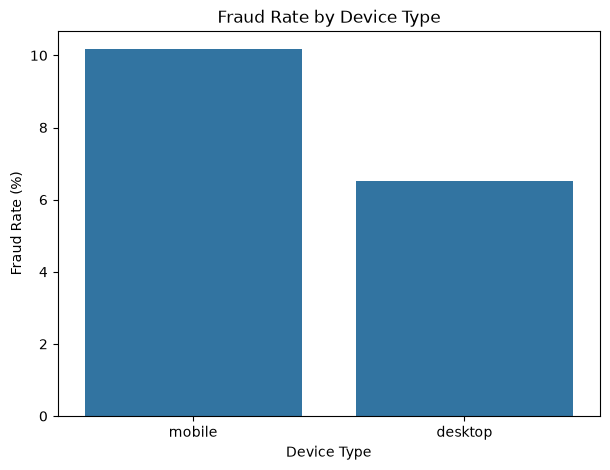

In [29]:
# Visualize Fraud Rate by Device Type
if "DeviceType" in train.columns:

    plt.figure(figsize=(7, 5))

    sns.barplot(
        x=device_fraud.index,
        y=device_fraud.values
    )

    plt.title("Fraud Rate by Device Type")
    plt.xlabel("Device Type")
    plt.ylabel("Fraud Rate (%)")

    plt.show()

## 10. Missingness and Fraud

Missing information may itself be associated with fraudulent behaviour, especially for device and identity attributes.

In [30]:
missing_rate_by_fraud = (
    train.groupby("isFraud")
    .apply(lambda x: x.isnull().mean().mean(), include_groups=False)
    .mul(100)
)

missing_rate_by_fraud

isFraud
0    45.149736
1    37.086655
dtype: float64

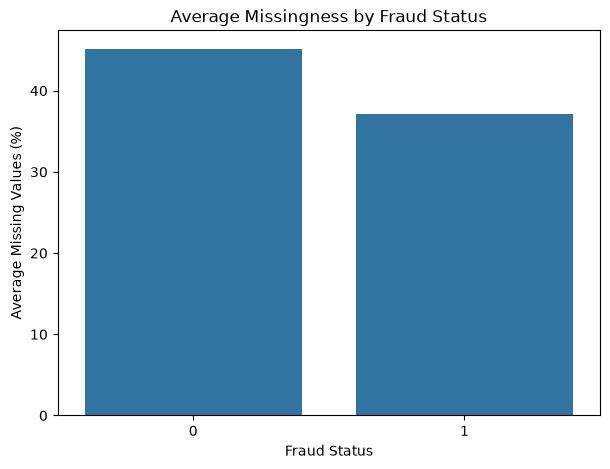

In [31]:
# Visualize Average Missingness by Fraud Status
plt.figure(figsize=(7, 5))

sns.barplot(
    x=missing_rate_by_fraud.index,
    y=missing_rate_by_fraud.values
)

plt.title("Average Missingness by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Average Missing Values (%)")

plt.show()

## 11. Feature Relationships

Examine correlations between selected numerical variables and the fraud target.

In [32]:
numeric_cols = train.select_dtypes(
    include=np.number
).columns

fraud_correlations = (
    train[numeric_cols]
    .corr()["isFraud"]
    .drop("isFraud")
    .abs()
    .sort_values(ascending=False)
)

fraud_correlations.head(20)

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float64

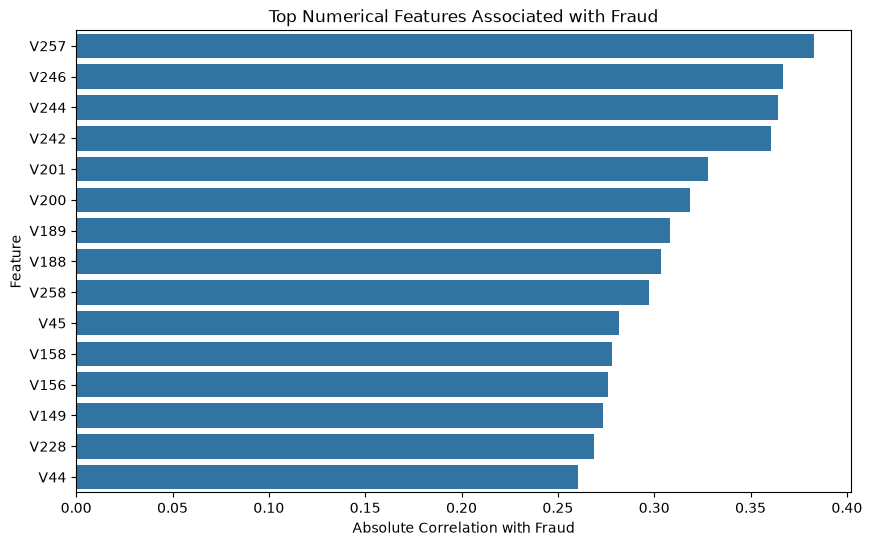

In [33]:
# Visualize Top Correlated Features with Fraud
top_corr_features = fraud_correlations.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_corr_features.values,
    y=top_corr_features.index
)

plt.title("Top Numerical Features Associated with Fraud")
plt.xlabel("Absolute Correlation with Fraud")
plt.ylabel("Feature")

plt.show()

## 12. High-Risk Feature Groups

Inspect selected high-association categorical or numerical features to identify potentially useful fraud signals.

In [34]:
top_features = fraud_correlations.head(10).index.tolist()

top_features

['V257', 'V246', 'V244', 'V242', 'V201', 'V200', 'V189', 'V188', 'V258', 'V45']

In [35]:
feature_summary = []

for col in top_features:
    feature_summary.append({
        "Feature": col,
        "Missing %": train[col].isnull().mean() * 100,
        "Unique Values": train[col].nunique()
    })

feature_summary = pd.DataFrame(feature_summary)

feature_summary

,Feature,Missing %,Unique Values
0,V257,77.913435,49
1,V246,77.913435,46
2,V244,77.913435,23
3,V242,77.913435,21
4,V201,76.323534,56
5,V200,76.323534,46
6,V189,76.323534,31
7,V188,76.323534,31
8,V258,77.913435,67
9,V45,28.612626,49


## 13. Key EDA Findings

The exploratory analysis highlights differences in transaction behaviour, timing, payment attributes, identity information and missingness between fraudulent and legitimate transactions.

These patterns will guide the feature-engineering stage and help identify variables that may be useful for fraud prediction.

### Main Areas Identified

- Fraud is highly imbalanced relative to legitimate transactions.
- Transaction amount distributions differ across fraud classes.
- Fraud rates vary across transaction hours.
- Card and payment attributes show differences in fraud behaviour.
- Device and identity information can provide additional fraud signals.
- Missingness may itself carry predictive information.
- Several numerical features show measurable association with the fraud target.

These findings provide the basis for the next stage: **Feature Engineering**.

In [36]:
eda_columns = [
    "AmountBin",
    "TransactionHour",
    "TransactionDay"
]

train_eda = train.drop(
    columns=[col for col in eda_columns if col in train.columns]
)

print("EDA analysis complete.")
print("Final EDA dataset shape:", train_eda.shape)

EDA analysis complete.
Final EDA dataset shape: (590540, 434)


# Conclusion

The fraud EDA identified transaction, temporal, payment, identity and missingness patterns that can inform fraud-focused feature engineering and modelling.